# Notebook 2 — Clustering & Hidden Pattern Discovery

**Goal:** Use unsupervised learning to discover natural groupings of governorates, detect temporal trajectory patterns, and mine non-obvious structures in the data.

This is the core **data mining** notebook. We are not describing what we already see — we are looking for structure the data hides.

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

df_gov = pd.read_csv('../data/bac_crosssectional.csv')
df_panel = pd.read_csv('../data/bac_panel.csv')
YEARS = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

print(f'Cross-sectional: {df_gov.shape}, Panel: {df_panel.shape}')

Cross-sectional: (26, 24), Panel: (208, 17)


## 1. Socioeconomic Profile Clustering

**Question:** Do governorates naturally group by socioeconomic profile — and do those groups correspond to BAC performance?

We use features: poverty rate, illiteracy rate, lycées per 1000, mean success rate, trend slope.

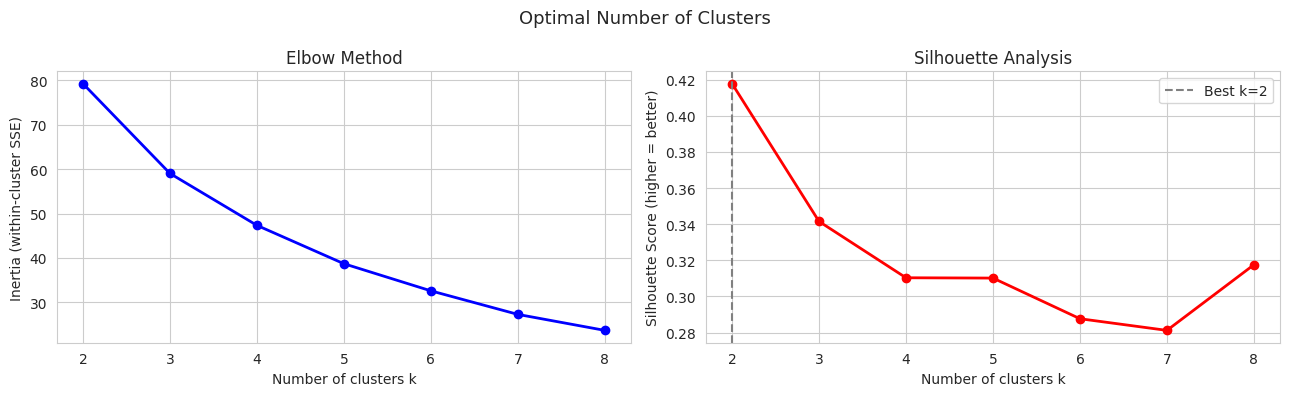

Optimal k by silhouette: 2


In [4]:
# Features for clustering
CLUSTER_FEATURES = ['poverty_rate', 'illiteracy_rate', 'lycees_per_1k',
                    'mean_rate', 'trend_slope', 'rank_volatility']

X = df_gov[CLUSTER_FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Elbow method + Silhouette score to find optimal k ---
inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(list(k_range), inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia (within-cluster SSE)')
ax1.set_title('Elbow Method')

ax2.plot(list(k_range), silhouettes, 'ro-', linewidth=2)
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette Score (higher = better)')
ax2.set_title('Silhouette Analysis')

best_k = list(k_range)[np.argmax(silhouettes)]
ax2.axvline(best_k, color='gray', linestyle='--', label=f'Best k={best_k}')
ax2.legend()

plt.suptitle('Optimal Number of Clusters', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/02_cluster_selection.png', dpi=150)
plt.show()
print(f'Optimal k by silhouette: {best_k}')

In [5]:
# Fit final KMeans with optimal k
K_FINAL = best_k
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_gov['cluster_kmeans'] = km_final.fit_predict(X_scaled)

# Label clusters meaningfully based on their characteristics
cluster_profiles = df_gov.groupby('cluster_kmeans')[CLUSTER_FEATURES + ['governorate']].agg(
    {f: 'mean' for f in CLUSTER_FEATURES} | {'governorate': list}
).round(2)

print('Cluster profiles (mean values):')
print(cluster_profiles[CLUSTER_FEATURES].to_string())
print('\nGovernorate memberships:')
for c, row in cluster_profiles.iterrows():
    print(f'  Cluster {c}: {row["governorate"]}')

Cluster profiles (mean values):
                poverty_rate  illiteracy_rate  lycees_per_1k  mean_rate  trend_slope  rank_volatility
cluster_kmeans                                                                                       
0                      10.89            15.19           0.04       45.5         2.73             1.43
1                      25.89            26.71           0.07       29.5         2.45             2.57

Governorate memberships:
  Cluster 0: ['Sfax 1', 'Sfax 2', 'Monastir', 'Mahdia', 'Sousse', 'Ariana', 'Nabeul', 'Tunis 1', 'Médenine', 'Tunis 2', 'Ben Arous', 'Bizerte', 'Gabès', 'Mannouba']
  Cluster 1: ['Zaghouan', 'Siliana', 'Béja', 'Kef', 'Kairouan', 'Kasserine', 'Sidi Bouzid', 'Tozeur', 'Tataouine', 'Kébili', 'Gafsa', 'Jendouba']


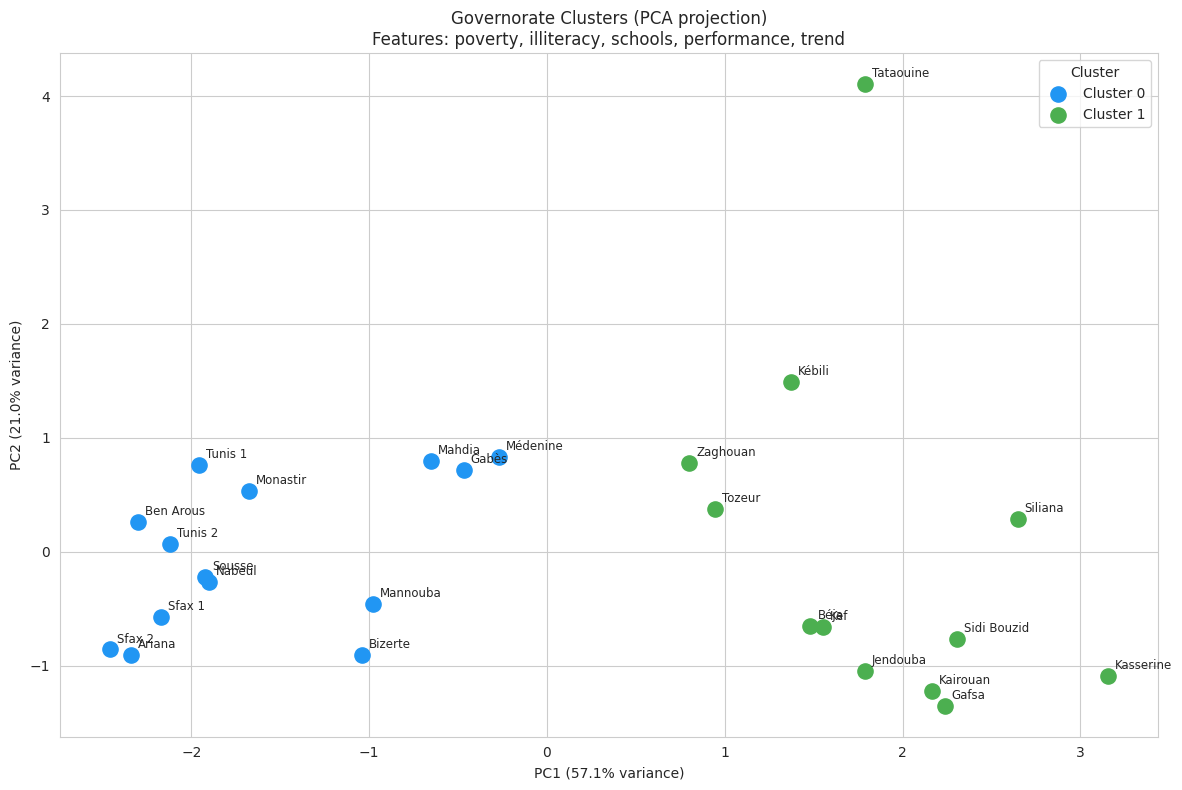

Total variance explained by PC1+PC2: 78.1%


In [6]:
# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_gov['pca1'] = X_pca[:, 0]
df_gov['pca2'] = X_pca[:, 1]

CLUSTER_COLORS = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#00BCD4']

fig, ax = plt.subplots(figsize=(12, 8))
for c in sorted(df_gov['cluster_kmeans'].unique()):
    subset = df_gov[df_gov['cluster_kmeans'] == c]
    ax.scatter(subset['pca1'], subset['pca2'],
               c=CLUSTER_COLORS[c], s=120, label=f'Cluster {c}', zorder=3)
    for _, row in subset.iterrows():
        ax.annotate(row['governorate'], (row['pca1'], row['pca2']),
                    fontsize=8.5, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Governorate Clusters (PCA projection)\nFeatures: poverty, illiteracy, schools, performance, trend')
ax.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.savefig('../outputs/02_pca_clusters.png', dpi=150)
plt.show()

print(f'Total variance explained by PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')

## 2. Hierarchical Clustering — Dendrogram

Hierarchical clustering reveals the nested structure of similarity — which governorates are closest to each other, which form natural sub-groups.

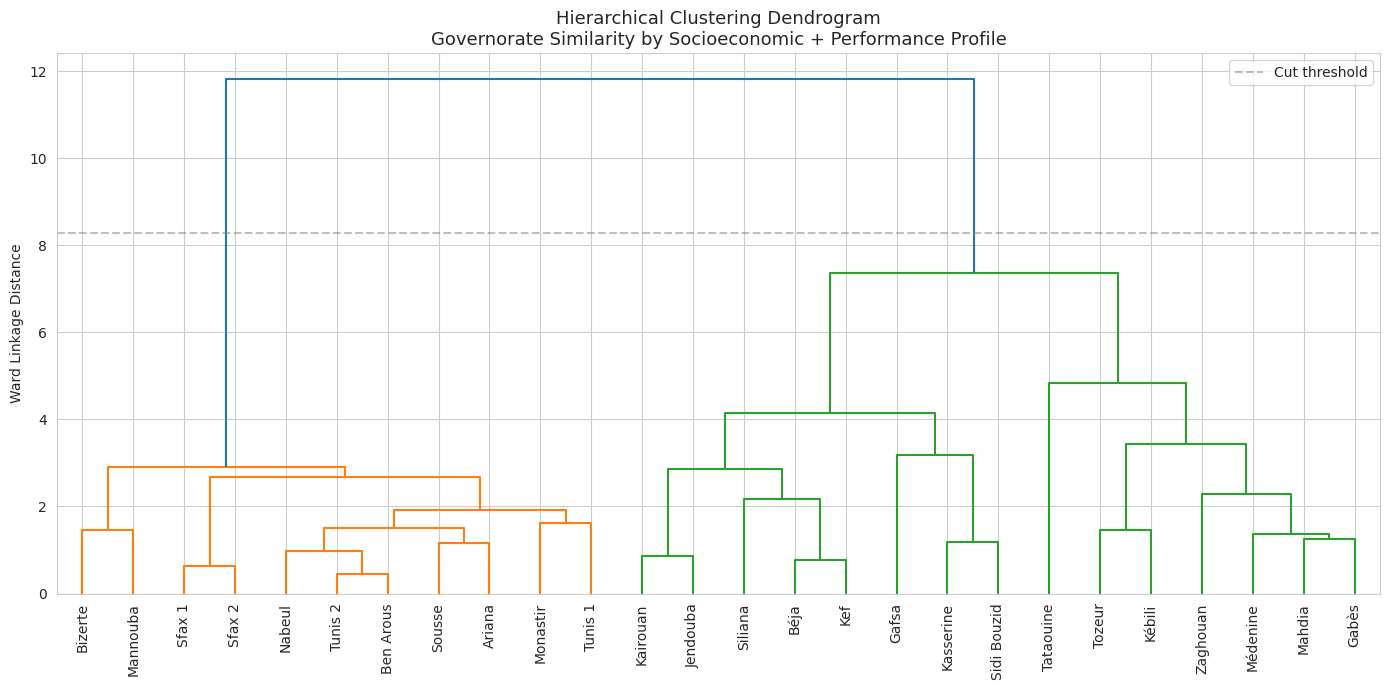

In [7]:
# Ward linkage hierarchical clustering
linkage_matrix = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(
    linkage_matrix,
    labels=df_gov['governorate'].values,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0.7 * max(linkage_matrix[:, 2]),
    ax=ax
)
ax.set_title('Hierarchical Clustering Dendrogram\nGovernorate Similarity by Socioeconomic + Performance Profile', fontsize=13)
ax.set_ylabel('Ward Linkage Distance')
ax.axhline(y=0.7 * max(linkage_matrix[:, 2]), color='gray', linestyle='--', alpha=0.5, label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/02_dendrogram.png', dpi=150)
plt.show()

## 3. Temporal Trajectory Clustering

**Hidden pattern question:** Do governorates follow similar *trajectories over time* even if they start from different baselines? This is different from clustering by socioeconomic profile — two governorates can be at opposite performance levels but follow the same pattern (both declined post-2022, both are improving, etc.).

We cluster on the sequence of success rates across 8 years.

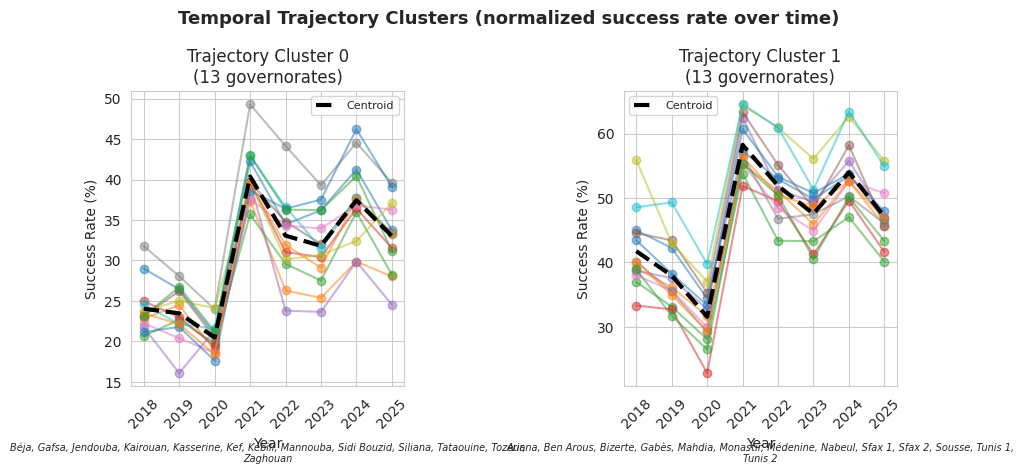

Trajectory cluster assignments:
  Cluster 0: ['Béja', 'Gafsa', 'Jendouba', 'Kairouan', 'Kasserine', 'Kef', 'Kébili', 'Mannouba', 'Sidi Bouzid', 'Siliana', 'Tataouine', 'Tozeur', 'Zaghouan']
  Cluster 1: ['Ariana', 'Ben Arous', 'Bizerte', 'Gabès', 'Mahdia', 'Monastir', 'Médenine', 'Nabeul', 'Sfax 1', 'Sfax 2', 'Sousse', 'Tunis 1', 'Tunis 2']


In [8]:
# Build trajectory matrix: 26 x 8 (governorates x years)
pivot = df_panel.pivot(index='governorate', columns='year', values='success_rate')
pivot_scaled = StandardScaler().fit_transform(pivot)  # normalize each governorate's trajectory

# Cluster trajectories
sil_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    sil_scores.append(silhouette_score(pivot_scaled, km.fit_predict(pivot_scaled)))

best_k_traj = np.argmax(sil_scores) + 2
km_traj = KMeans(n_clusters=best_k_traj, random_state=42, n_init=20)
traj_labels = km_traj.fit_predict(pivot_scaled)
pivot['traj_cluster'] = traj_labels

fig, axes = plt.subplots(1, best_k_traj, figsize=(5 * best_k_traj, 5), sharey=False)
if best_k_traj == 1:
    axes = [axes]

for c, ax in enumerate(axes):
    group = pivot[pivot['traj_cluster'] == c].drop(columns='traj_cluster')
    for gov, row in group.iterrows():
        ax.plot(YEARS, row.values, 'o-', alpha=0.5, linewidth=1.5)
    # Plot cluster centroid
    ax.plot(YEARS, group.mean().values, 'k--', linewidth=3, label='Centroid')
    ax.set_title(f'Trajectory Cluster {c}\n({len(group)} governorates)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Success Rate (%)')
    ax.set_xticks(YEARS)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    govs = ", ".join(group.index.tolist())
    ax.text(0.5, -0.25, govs, transform=ax.transAxes, fontsize=7,
            ha='center', wrap=True, style='italic')

plt.suptitle('Temporal Trajectory Clusters (normalized success rate over time)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_trajectory_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Trajectory cluster assignments:')
for c in range(best_k_traj):
    govs = pivot[pivot['traj_cluster'] == c].index.tolist()
    print(f'  Cluster {c}: {govs}')

## 4. Threshold Effect Detection

**Hidden pattern question:** Is the relationship between poverty/illiteracy and BAC success linear, or is there a threshold beyond which performance collapses? This is a non-obvious pattern — standard correlation misses it.

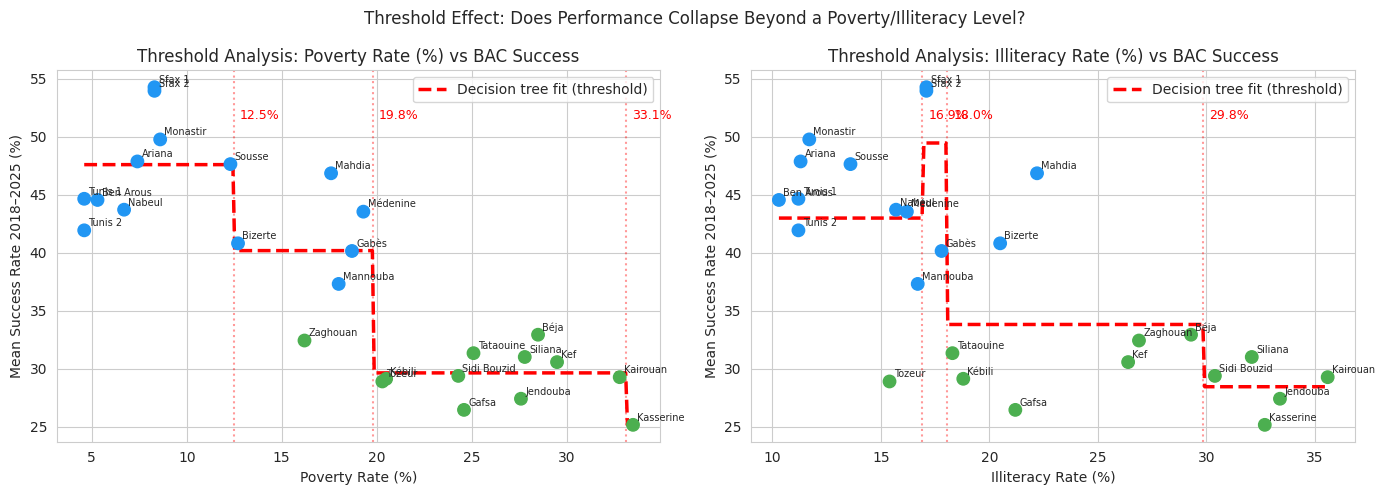

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature, label in zip(axes, ['poverty_rate', 'illiteracy_rate'],
                               ['Poverty Rate (%)', 'Illiteracy Rate (%)']):
    x = df_gov[feature].values
    y = df_gov['mean_rate'].values
    
    # Fit a shallow decision tree to find split points
    dt = DecisionTreeRegressor(max_depth=2, random_state=42)
    dt.fit(x.reshape(-1, 1), y)
    
    # Plot scatter
    ax.scatter(x, y, c=df_gov['cluster_kmeans'].map({i: CLUSTER_COLORS[i]
               for i in range(K_FINAL)}), s=80, zorder=3)
    
    # Plot decision tree prediction (step function)
    x_line = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
    ax.plot(x_line, dt.predict(x_line), 'r--', linewidth=2.5, label='Decision tree fit (threshold)')
    
    # Mark thresholds
    for thresh in dt.tree_.threshold[dt.tree_.threshold > 0]:
        ax.axvline(thresh, color='red', alpha=0.4, linestyle=':', linewidth=1.5)
        ax.text(thresh + 0.3, y.max() * 0.95, f'{thresh:.1f}%', color='red', fontsize=9)
    
    ax.set_xlabel(label)
    ax.set_ylabel('Mean Success Rate 2018–2025 (%)')
    ax.set_title(f'Threshold Analysis: {label} vs BAC Success')
    ax.legend()
    
    # Annotate each point
    for _, row in df_gov.iterrows():
        ax.annotate(row['governorate'], (row[feature], row['mean_rate']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')

plt.suptitle('Threshold Effect: Does Performance Collapse Beyond a Poverty/Illiteracy Level?', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/02_threshold_effects.png', dpi=150)
plt.show()

## 5. Rank Mobility Analysis

**Hidden pattern question:** Which governorates climbed or fell the most in rankings? This reveals mobility — some regions escape their structural constraints, others don't.

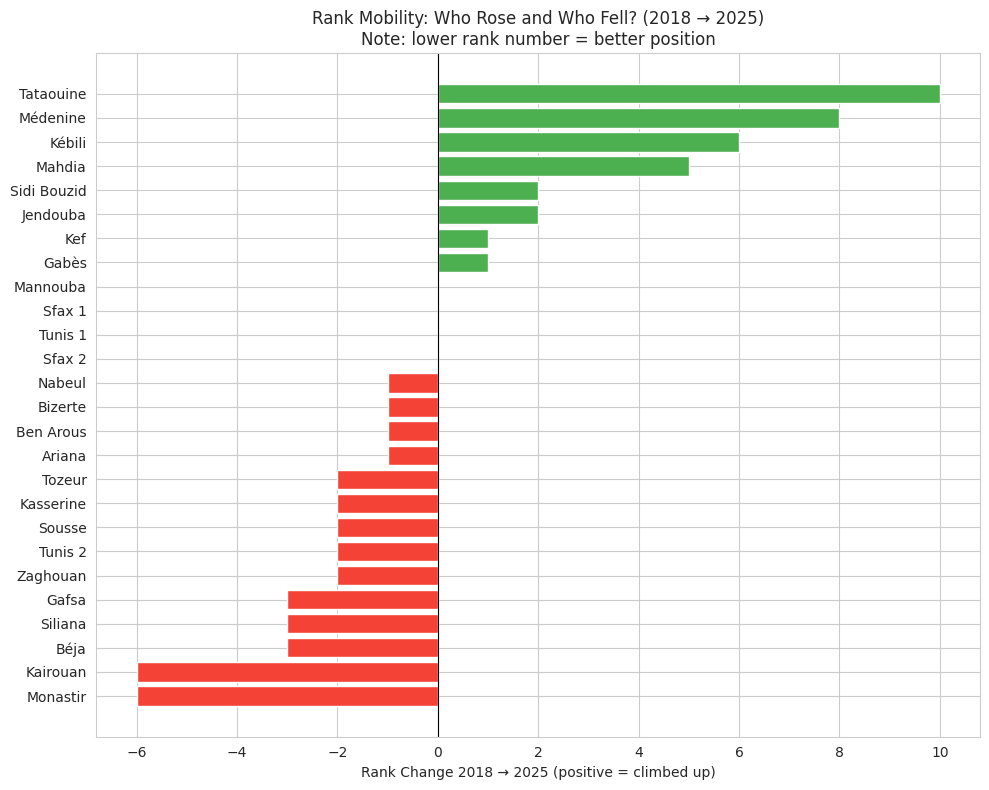

Biggest climbers:
governorate  rank_change
Sidi Bouzid            2
     Mahdia            5
     Kébili            6
   Médenine            8
  Tataouine           10

Biggest fallers:
governorate  rank_change
   Monastir           -6
   Kairouan           -6
       Béja           -3
    Siliana           -3
      Gafsa           -3


In [10]:
rank_2018 = df_panel[df_panel['year'] == 2018].set_index('governorate')['rank']
rank_2025 = df_panel[df_panel['year'] == 2025].set_index('governorate')['rank']
rank_change = (rank_2018 - rank_2025).reset_index()  # positive = climbed (lower rank number = better)
rank_change.columns = ['governorate', 'rank_change']
rank_change = rank_change.sort_values('rank_change', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#4CAF50' if v > 0 else '#F44336' for v in rank_change['rank_change']]
ax.barh(rank_change['governorate'], rank_change['rank_change'], color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Rank Change 2018 → 2025 (positive = climbed up)')
ax.set_title('Rank Mobility: Who Rose and Who Fell? (2018 → 2025)\nNote: lower rank number = better position')
plt.tight_layout()
plt.savefig('../outputs/02_rank_mobility.png', dpi=150)
plt.show()

print('Biggest climbers:')
print(rank_change.tail(5).to_string(index=False))
print('\nBiggest fallers:')
print(rank_change.head(5).to_string(index=False))

## 6. Association Pattern — School Infrastructure & Performance

**Hidden pattern question:** Does the *type* of school infrastructure (primary-heavy vs lycée-heavy) associate with performance differently? We use a simple binning approach to surface this.

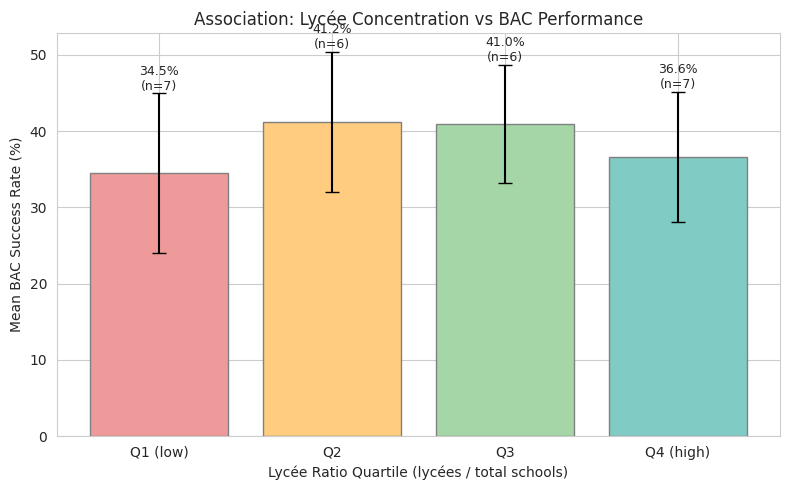

In [11]:
df_gov['lycee_ratio'] = df_gov['nb_lycees'] / df_gov['nb_total']   # lycées as % of all schools
df_gov['primary_ratio'] = df_gov['nb_primaires'] / df_gov['nb_total']

# Bin by lycée ratio quartile
df_gov['lycee_quartile'] = pd.qcut(df_gov['lycee_ratio'], q=4,
                                    labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

assoc = df_gov.groupby('lycee_quartile')['mean_rate'].agg(['mean', 'std', 'count'])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(assoc.index.astype(str), assoc['mean'], yerr=assoc['std'],
               capsize=5, color=['#EF9A9A', '#FFCC80', '#A5D6A7', '#80CBC4'], edgecolor='gray')
ax.set_xlabel('Lycée Ratio Quartile (lycées / total schools)')
ax.set_ylabel('Mean BAC Success Rate (%)')
ax.set_title('Association: Lycée Concentration vs BAC Performance')
for bar, (_, row) in zip(bars, assoc.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + row['std'] + 0.5,
            f"{row['mean']:.1f}%\n(n={int(row['count'])})", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/02_association_lycees.png', dpi=150)
plt.show()

## 7. Save Cluster Labels for Next Notebooks

In [12]:
df_gov.to_csv('../data/bac_crosssectional.csv', index=False)
print('Updated cross-sectional file saved with cluster labels.')
print('Columns added: cluster_kmeans, pca1, pca2, traj_cluster (in pivot), lycee_ratio, lycee_quartile')

Updated cross-sectional file saved with cluster labels.
Columns added: cluster_kmeans, pca1, pca2, traj_cluster (in pivot), lycee_ratio, lycee_quartile
